In [1]:
!pip install -q transformers diffusers accelerate datasets timm
# transformers: libreria HuggingFace per modelli pre-addestrati
# diffusers: libreria HuggingFace per Stable Diffusion
# accelerate: ottimizza l'uso della GPU con HuggingFace
# datasets: gestione dataset HuggingFace
# timm: modelli di computer vision pre-addestrati

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import json
import random
from pathlib import Path
from collections import Counter

# Impostiamo il seed per la riproducibilità
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Definiamo il device. Useremo la GPU se disponibile, altrimenti la CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in uso: {DEVICE}")

Device in uso: cuda


In [3]:
# Definiamo le trasformazioni di base per il download iniziale
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ridimensioniamo a 224x224 (standard per ResNet)
    transforms.ToTensor(),          # Convertiamo PIL Image in tensore PyTorch
])

# Scarichiamo il dataset. # split="trainval" scarica la porzione di training+validation
dataset_full = OxfordIIITPet(root="./data", split="trainval", transform=basic_transform, download=True)
dataset_test = OxfordIIITPet(root="./data", split="test", transform=basic_transform, download=True)

print(f"Dataset di training: {len(dataset_full)} immagini")
print(f"\nDataset di test: {len(dataset_test)} immagini")

100%|██████████| 792M/792M [02:36<00:00, 5.06MB/s]
100%|██████████| 19.2M/19.2M [00:04<00:00, 4.39MB/s]


Dataset di training: 3680 immagini

Dataset di test: 3669 immagini


In [4]:
# Esploriamo il dataset. Vediamo quante classi ci sono e come sono distribuite

print(f"Numero di classi: {len(dataset_full.classes)}")
print(f"\nPrime 5 classi: {dataset_full.classes[:5]}")

# Contiamo quante immagini ci sono per ogni classe
label_counts = Counter(dataset_full._labels)
print(f"\nDistribuzione delle prime 5 classi:")
for class_idx, count in sorted(label_counts.items())[:5]:
    class_name = dataset_full.classes[class_idx]
    print(f"  {class_name}: {count} immagini")

Numero di classi: 37

Prime 5 classi: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']

Distribuzione delle prime 5 classi:
  Abyssinian: 100 immagini
  American Bulldog: 100 immagini
  American Pit Bull Terrier: 100 immagini
  Basset Hound: 100 immagini
  Beagle: 100 immagini


In [5]:
# Visualizziamo un campione casuale di immagini

def visualizza_campione(dataset, num_immagini=12, titolo="Campioni"):
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle(titolo, fontsize=16, fontweight='bold')

    # Scegliamo indici casuali
    indices = random.sample(range(len(dataset)), num_immagini)

    for idx, ax in zip(indices, axes.flatten()):
        immagine, label = dataset[idx]

        # Il tensore ha forma [C, H, W] — dobbiamo portarlo a [H, W, C] per matplotlib
        immagine_np = immagine.permute(1, 2, 0).numpy()

        # Clip per evitare valori fuori range dopo le trasformazioni
        immagine_np = np.clip(immagine_np, 0, 1)

        ax.imshow(immagine_np)
        ax.set_title(dataset.classes[label], fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualizza_campione(dataset_full)

Output hidden; open in https://colab.research.google.com to view.

In [6]:
# Creiamo il sottoinsieme ridotto. Prendiamo solo 5 classi su 37 e solo 20 immagini per classe
NUM_CLASSI = 5          # Numero di classi che useremo
IMG_PER_CLASSE = 20     # Immagini per classe nel dataset ridotto

# Scegliamo le prime 5 classi per semplicità
classi_scelte = list(range(NUM_CLASSI))
nomi_classi = [dataset_full.classes[i] for i in classi_scelte]
print(f"Classi scelte: {nomi_classi}")

def crea_subset_bilanciato(dataset, classi, img_per_classe, seed=42):
    random.seed(seed)

    # Raggruppiamo gli indici per classe. Per ogni classe, raccogliamo tutti gli indici delle immagini di quella classe
    indici_per_classe = {c: [] for c in classi}

    for idx, label in enumerate(dataset._labels):
        if label in classi:
            indici_per_classe[label].append(idx)

    # Selezioniamo casualmente immagini per ogni classe
    indices_finali = []
    for classe in classi:
        campionati = random.sample(indici_per_classe[classe], img_per_classe)
        indices_finali.extend(campionati)

    # Creiamo una mappa che porta le etichette originali a 0,1,2,.. Es: se le classi scelte sono [3,7,12], la mappa sarà {3:0, 7:1, 12:2}
    label_map = {classe_orig: nuovo_idx
                 for nuovo_idx, classe_orig in enumerate(classi)}

    return indices_finali, label_map

# Creiamo il subset
indices_ridotti, label_map = crea_subset_bilanciato(dataset_full, classi_scelte, IMG_PER_CLASSE)
print(f"\nLabel map: {label_map}")

# Salviamo gli indici e la label map per usarli nelle fasi successive
# json non accetta chiavi intere, le convertiamo in stringhe
with open("./indices_ridotti.json", "w") as f:
    json.dump({
        "indices": indices_ridotti,
        "label_map": {str(k): v for k, v in label_map.items()},
        "classi_scelte": classi_scelte,
        "nomi_classi": nomi_classi
    }, f)

Classi scelte: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']

Label map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [7]:
# Verifichiamo che il subset sia corretto visualizzando alcune immagini e controllando la distribuzione delle classi
subset = Subset(dataset_full, indices_ridotti)
print(f"Dimensione subset: {len(subset)} immagini")

# Verifichiamo la distribuzione — deve essere perfettamente bilanciata
labels_subset = [dataset_full._labels[i] for i in indices_ridotti]
distribuzione = Counter(labels_subset)
print(f"\nDistribuzione per classe:")
for class_idx, count in sorted(distribuzione.items()):
    print(f"  {dataset_full.classes[class_idx]}: {count} immagini")

Dimensione subset: 100 immagini

Distribuzione per classe:
  Abyssinian: 20 immagini
  American Bulldog: 20 immagini
  American Pit Bull Terrier: 20 immagini
  Basset Hound: 20 immagini
  Beagle: 20 immagini


Per ogni immagine del nostro subset ridotto, genereremo automaticamente una descrizione testuale. Useremo BLIP, un modello di Salesforce disponibile gratuitamente su HuggingFace che prende un'immagine in input e produce una frase descrittiva in inglese.

In [8]:
from transformers import BlipProcessor, BlipForConditionalGeneration

# Ricarichiamo le configurazioni salvate nella Fase 1
with open("./indices_ridotti.json", "r") as f:
    config = json.load(f)

indices_ridotti = config["indices"]
label_map = {int(k): v for k, v in config["label_map"].items()}
classi_scelte = config["classi_scelte"]
nomi_classi = config["nomi_classi"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Classi: {nomi_classi}")
print(f"Immagini nel subset: {len(indices_ridotti)}")

# Carichiamo BLIP da HuggingFace. BlipProcessor gestisce il preprocessing dell'immagine. BlipForConditionalGeneration è il modello vero e proprio
MODEL_NAME = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model_blip = BlipForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(DEVICE)

# Mettiamo il modello in modalità evaluation, questo disabilita il dropout e altre tecniche usate solo durante il training
model_blip.eval()

print(f"Parametri del modello: {sum(p.numel() for p in model_blip.parameters()):,}")

Device: cuda
Classi: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']
Immagini nel subset: 100


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Parametri del modello: 247,444,600


In [9]:
# Definiamo solo il resize per uniformità. Il processor di BLIP farà il resto
transform_per_captioning = transforms.Compose([
    transforms.Resize((384, 384)),  # BLIP è addestrato su 384x384
])

# Carichiamo il dataset con questa trasformazione minimale
dataset_per_captioning = OxfordIIITPet(
    root="./data",
    split="trainval",
    transform=transform_per_captioning,
    download=False  # Già scaricato nella Fase 1
)

# Funzione per ottenere l'immagine PIL originale dato un indice
def get_pil_image(dataset, idx):
    image, label = dataset[idx]
    # La trasformazione ha già fatto il resize ma l'immagine è ancora PIL
    return image, label

# Test rapido
img_test, label_test = get_pil_image(dataset_per_captioning, indices_ridotti[0])
print(f"Tipo immagine: {type(img_test)}")
print(f"Dimensione immagine: {img_test.size}")
print(f"Label: {label_test} ({nomi_classi[label_map[label_test]]})")

Tipo immagine: <class 'PIL.Image.Image'>
Dimensione immagine: (384, 384)
Label: 0 (Abyssinian)


Classe: Abyssinian
Caption generata: 'a cat with a flower in its mouth'


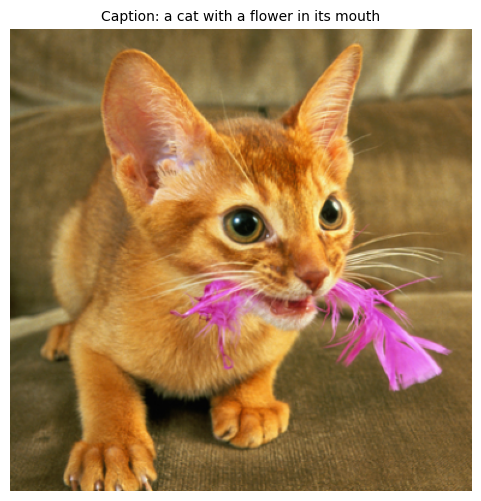

In [10]:
# Genera una caption testuale per una singola immagine usando BLIP.
def genera_caption(model, processor, image, device, max_length=50):
    # Il processor converte la PIL Image nel formato che BLIP si aspetta: normalizzazione, conversione in tensore, aggiunta della dimensione batch (da [C,H,W] a [1,C,H,W])
    inputs = processor(images=image, return_tensors="pt").to(device, torch.float16)

    # Generiamo la caption
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=max_length,      # Lunghezza massima della caption
            num_beams=4,                # Beam search con 4 beam
            early_stopping=True,        # Si ferma quando tutti i beam sono completati
            repetition_penalty=1.3      # Penalizza la ripetizione delle stesse parole
        )

    # Decodifichiamo gli ID dei token in testo leggibile. skip_special_tokens=True rimuove token come [PAD], [EOS], ecc.
    caption = processor.decode(output_ids[0], skip_special_tokens=True)

    return caption

# Test su una singola immagine
img_test, label_test = get_pil_image(dataset_per_captioning, indices_ridotti[0])
caption_test = genera_caption(model_blip, processor, img_test, DEVICE)

print(f"Classe: {nomi_classi[label_map[label_test]]}")
print(f"Caption generata: '{caption_test}'")

# Visualizziamo
plt.figure(figsize=(6, 6))
plt.imshow(img_test)
plt.title(f"Caption: {caption_test}", wrap=True, fontsize=10)
plt.axis('off')
plt.show()

In [11]:
import time

def genera_tutte_le_caption(dataset, indices, label_map, nomi_classi, model, processor, device):
    risultati = []
    # Controlliamo se esiste già un file di salvataggio parziale
    checkpoint_path = "./captions_checkpoint.json"
    indici_già_processati = set()

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            risultati = json.load(f)
        indici_già_processati = {r["dataset_idx"] for r in risultati}
        print(f"Ripresa da checkpoint: {len(risultati)} caption già generate")

    # Calcoliamo quante immagini dobbiamo ancora processare
    da_processare = [idx for idx in indices if idx not in indici_già_processati]
    print(f"Caption da generare: {len(da_processare)}")

    start_time = time.time()

    for i, dataset_idx in enumerate(da_processare):
        # Recuperiamo l'immagine e la label
        image, label_originale = get_pil_image(dataset, dataset_idx)

        # Otteniamo il nome della classe
        label_nuova = label_map[label_originale]
        nome_classe = nomi_classi[label_nuova]

        # Generiamo la caption
        caption = genera_caption(model, processor, image, device)

        # Salviamo il risultato
        risultato = {
            "dataset_idx": dataset_idx,       # Indice nel dataset originale
            "label_originale": label_originale, # Etichetta originale (0-36)
            "label_nuova": label_nuova,         # Etichetta nel nostro subset (0-4)
            "nome_classe": nome_classe,          # Nome leggibile della classe
            "caption": caption                   # Caption generata da BLIP
        }
        risultati.append(risultato)

        # Salviamo il checkpoint ogni 10 immagini
        if (i + 1) % 10 == 0:
            with open(checkpoint_path, "w") as f:
                json.dump(risultati, f, indent=2)

            # Stimiamo il tempo rimanente
            elapsed = time.time() - start_time
            img_processate = i + 1
            img_totali = len(da_processare)
            tempo_per_img = elapsed / img_processate
            tempo_rimanente = tempo_per_img * (img_totali - img_processate)

            print(f"[{img_processate}/{img_totali}] "
                  f"Ultima caption: '{caption[:50]}...' | "
                  f"Tempo rimanente stimato: {tempo_rimanente:.0f}s")

    # Salvataggio finale completo
    with open("./captions_finali.json", "w") as f:
        json.dump(risultati, f, indent=2)

    print(f"\n{len(risultati)} caption salvate in captions_finali.json")
    return risultati

# Avviamo la generazione
captions = genera_tutte_le_caption(dataset_per_captioning, indices_ridotti, label_map, nomi_classi, model_blip, processor, DEVICE)

Caption da generare: 100
[10/100] Ultima caption: 'a cat standing on top of a bed...' | Tempo rimanente stimato: 27s
[20/100] Ultima caption: 'an orange cat laying on top of a table...' | Tempo rimanente stimato: 23s
[30/100] Ultima caption: 'a brown and white dog laying on a bed...' | Tempo rimanente stimato: 19s
[40/100] Ultima caption: 'a white and brown dog sitting on a chair...' | Tempo rimanente stimato: 16s
[50/100] Ultima caption: 'a dog sitting on top of a wooden bench...' | Tempo rimanente stimato: 13s
[60/100] Ultima caption: 'a white and brown dog sitting in the grass...' | Tempo rimanente stimato: 10s
[70/100] Ultima caption: 'the dog is brown and white...' | Tempo rimanente stimato: 8s
[80/100] Ultima caption: 'a brown and white dog sitting on a tiled floor...' | Tempo rimanente stimato: 5s
[90/100] Ultima caption: 'a brown and white dog with a black collar...' | Tempo rimanente stimato: 3s
[100/100] Ultima caption: 'a small brown and white dog laying on a red blanke...' 

In [12]:
from transformers import T5ForConditionalGeneration, T5Tokenizer, AutoTokenizer

# Prima di caricare un nuovo modello su Colab gratuito dobbiamo liberare la memoria GPU occupata da BLIP nella Fase 2
if 'model_blip' in globals():
    del model_blip
    del processor
    torch.cuda.empty_cache()  # Svuotiamo la cache della GPU
    print("Memoria GPU liberata da BLIP")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ricarichiamo le caption generate nella Fase 2
with open("./captions_finali.json", "r") as f:
    captions = json.load(f)

with open("./indices_ridotti.json", "r") as f:
    config = json.load(f)

nomi_classi = config["nomi_classi"]

print(f"Caption caricate: {len(captions)}")

Memoria GPU liberata da BLIP
Caption caricate: 100


In [13]:
# Usiamo la versione large di Flan-T5, con 780M parametri gestibile su T4 con float16
MODEL_NAME = "google/flan-t5-large"

# Il tokenizer converte il testo in token numerici e viceversa
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Carichiamo il modello in float16 per risparmiare memoria
model_t5 = T5ForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(DEVICE)

model_t5.eval()

print(f"Flan-T5 Large caricato!")
print(f"Parametri: {sum(p.numel() for p in model_t5.parameters()):,}")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Flan-T5 Large caricato!
Parametri: 783,150,080


In [14]:
# Costruisce il prompt da dare a Flan-T5 per generare varianti di una caption esistente.
def costruisci_prompt(caption, nome_classe, num_varianti=3):

    nome_leggibile = nome_classe.replace("_", " ").lower()

    # Usiamo il prefisso nativo 'paraphrase:' di Flan-T5
    prompt = f"paraphrase: {caption} The animal is a {nome_leggibile}."

    return prompt

In [18]:
#Genera varianti testuali di una caption usando beam search diversificata
def genera_varianti(model, tokenizer, caption, nome_classe, num_varianti=3, device=DEVICE):

    prompt = costruisci_prompt(caption, nome_classe, num_varianti)

    inputs = tokenizer(prompt, return_tensors="pt", max_length=128, truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            num_return_sequences=num_varianti,
            num_beams=6,                    # 6 beam totali
            num_beam_groups=3,              # Divisi in 3 gruppi da 2
            diversity_penalty=1.0,          # Penalizza output simili tra gruppi
            do_sample=False,                # Niente campionamento
            repetition_penalty=1.5,         # Penalizza ripetizioni di parole
            early_stopping=True,
            trust_remote_code=True          # Aggiunto per abilitare Group Beam Search
        )

    varianti_raw = [
        tokenizer.decode(output, skip_special_tokens=True)
        for output in outputs
    ]

    # Post-processing: puliamo e filtriamo
    varianti_pulite = []
    for variante in varianti_raw:
        variante = variante.strip()

        # Scartiamo varianti identiche alla caption originale e varianti troppo corte (meno di 5 parole)
        if (variante.lower() != caption.lower()
                and len(variante.split()) >= 5):
            varianti_pulite.append(variante)

    return varianti_pulite[:num_varianti]

In [20]:
#Genera varianti per tutte le caption del subset.
NUM_VARIANTI = 3  # Varianti per ogni caption. Con 100 immagini → 300 varianti totali
def genera_tutte_le_varianti(captions, model, tokenizer, num_varianti=3, device=DEVICE):
    checkpoint_path = "./varianti_checkpoint.json"
    dataset_testuale = []
    indici_processati = set()

    # Riprendiamo da checkpoint se esiste
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            dataset_testuale = json.load(f)
        indici_processati = {r["dataset_idx"] for r in dataset_testuale}

    da_processare = [c for c in captions if c["dataset_idx"] not in indici_processati]
    print(f"Caption da processare: {len(da_processare)}")

    start_time = time.time()

    for i, cap_data in enumerate(da_processare):

        # Generiamo le varianti per questa caption
        varianti = genera_varianti(
            model, tokenizer,
            cap_data["caption"],
            cap_data["nome_classe"],
            num_varianti=num_varianti,
            device=device
        )

        # Costruiamo l'entry completa per questa immagine. Includiamo sia la caption originale che tutte le varianti
        entry = {
            "dataset_idx": cap_data["dataset_idx"],
            "label_nuova": cap_data["label_nuova"],
            "nome_classe": cap_data["nome_classe"],
            "caption_originale": cap_data["caption"],
            "varianti": varianti,
            # Lista completa: originale + varianti. Questa sarà l'input per la generazione di immagini
            "tutti_i_testi": [cap_data["caption"]] + varianti
        }

        dataset_testuale.append(entry)

    # Salvataggio finale
    with open("./dataset_testuale_finale.json", "w") as f:
        json.dump(dataset_testuale, f, indent=2, ensure_ascii=False)

    return dataset_testuale

# Avviamo la generazione
dataset_testuale = genera_tutte_le_varianti(captions, model_t5, tokenizer, num_varianti=NUM_VARIANTI)

Caption da processare: 80


Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

In [21]:
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# Liberiamo la memoria GPU da Flan-T5
if 'model_t5' in globals():
    del model_t5
    del tokenizer
    torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carichiamo il dataset testuale dalla Fase 3
with open("./dataset_testuale_finale.json", "r") as f:
    dataset_testuale = json.load(f)

with open("./indices_ridotti.json", "r") as f:
    config = json.load(f)

nomi_classi = config["nomi_classi"]

print(f"Entry caricate: {len(dataset_testuale)}")
print(f"Classi: {nomi_classi}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Entry caricate: 100
Classi: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


In [22]:
# Usiamo Stable Diffusion v1.4
MODEL_SD = "CompVis/stable-diffusion-v1-4"

# Carichiamo la pipeline completa. Racchiude tutto il processo di generazione: tokenizzazione del prompt, encoding testuale, reverse diffusion, decoding VAE
pipeline = StableDiffusionPipeline.from_pretrained(
    MODEL_SD,
    torch_dtype=torch.float16,   # Float16 dimezza l'uso della memoria
    safety_checker=None,          # Disabilitiamo il safety checker per velocizzare
    requires_safety_checker=False
)

# Sostituiamo lo scheduler (definisce quanti passi fare, quanto rumore rimuovere ad ogni step) di default con DPMSolverMultistep. Questo scheduler converge in soli 20 step invece dei 50 standard
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)

# Spostiamo la pipeline sulla GPU
pipeline = pipeline.to(DEVICE)

print("Stable Diffusion caricato e ottimizzato per Colab!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion caricato e ottimizzato per Colab!


  0%|          | 0/20 [00:00<?, ?it/s]

Generata in 3.8s — dimensione: (512, 512)


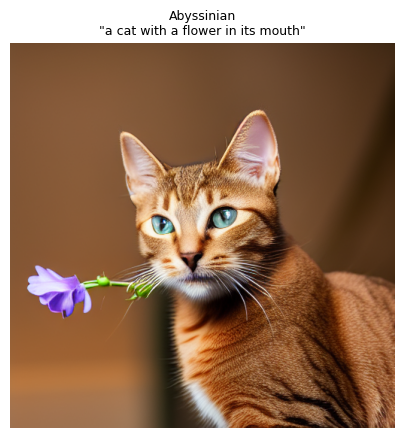

In [23]:
#Costruisce un prompt ottimizzato per Stable Diffusion
def costruisci_prompt_sd(testo_base, nome_classe):
    nome_leggibile = nome_classe.replace("_", " ").lower()

    # Il prompt positivo descrive cosa vogliamo vedere
    prompt = (
        f"{testo_base}, {nome_leggibile}, "
        f"high quality photo, sharp focus, "
        f"natural lighting, realistic, detailed"
    )

    # Il negative prompt descrive cosa non vogliamo
    negative_prompt = ("blurry, low quality, distorted, deformed, painting, illustration, worst quality, low resolution, text")

    return prompt, negative_prompt

#Genera una singola immagine con Stable Diffusion
def genera_immagine_pil(pipeline, testo, nome_classe, seed=None, num_steps=20, guidance_scale=7.5):
    prompt, negative_prompt = costruisci_prompt_sd(testo, nome_classe)

    generator = None
    if seed is not None:
        generator = torch.Generator(device=DEVICE).manual_seed(seed)

    with torch.no_grad():
        result = pipeline(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=num_steps,
            guidance_scale=guidance_scale,
            width=512,
            height=512,
            generator=generator
        )

    return result.images[0], prompt


# Test rapido
testo_test = dataset_testuale[0]["caption_originale"]
classe_test = dataset_testuale[0]["nome_classe"]

start = time.time()
img_test, prompt_test = genera_immagine_pil(
    pipeline, testo_test, classe_test, seed=42
)
elapsed = time.time() - start

print(f"Generata in {elapsed:.1f}s — dimensione: {img_test.size}")

plt.figure(figsize=(5, 5))
plt.imshow(img_test)
plt.title(f"{classe_test}\n\"{testo_test[:50]}\"", fontsize=9)
plt.axis('off')
plt.show()

In [24]:
# Generazione del dataset aumentato. Per ogni immagine originale generiamo 2 nuove immagini usando 2 delle 3 varianti testuali prodotte nella Fase 3. Dataset finale: 100 + 200 = 300 immagini

NUM_PER_ORIGINALE = 2

def genera_dataset_in_memoria(dataset_testuale, pipeline, num_per_originale=2):
    # Carichiamo il dataset originale per recuperare le immagini
    transform_base = transforms.Compose([transforms.Resize((512, 512))])

    dataset_orig = OxfordIIITPet(
        root="./data",
        split="trainval",
        transform=transform_base,
        download=False
    )

    dataset_memoria = {"originali": [], "generate": []
    }

    totale_da_generare = len(dataset_testuale) * num_per_originale
    print(f"Raccolta immagini originali: {len(dataset_testuale)}")
    print(f"Immagini da generare: {totale_da_generare}")

    # Raccolta immagini originale
    for entry in dataset_testuale:
        idx = entry["dataset_idx"]
        label = entry["label_nuova"]
        nome_classe = entry["nome_classe"]

        # Recuperiamo la PIL Image originale
        image, _ = dataset_orig[idx]

        dataset_memoria["originali"].append({
            "image": image,          # PIL Image 512x512
            "label": label,          # Etichetta 0-4
            "nome_classe": nome_classe,
            "dataset_idx": idx
        })

    print(f"  {len(dataset_memoria['originali'])} originali in memoria")

    # Generazione immagini sintetiche
    start_time = time.time()
    contatore = 0

    for entry in dataset_testuale:
        idx = entry["dataset_idx"]
        label = entry["label_nuova"]
        nome_classe = entry["nome_classe"]

        # Usiamo le prime num_per_originale varianti
        varianti_da_usare = entry["varianti"][:num_per_originale]

        for var_idx, testo in enumerate(varianti_da_usare):

            # Seed deterministico e riproducibile
            seed = idx * 100 + var_idx

            # Generiamo l'immagine — rimane in memoria come PIL Image
            image, prompt_usato = genera_immagine_pil(
                pipeline,
                testo,
                nome_classe,
                seed=seed,
                num_steps=20
            )

            dataset_memoria["generate"].append({
                "image": image,              # PIL Image 512x512
                "label": label,              # Etichetta 0-4
                "nome_classe": nome_classe,
                "testo": testo,
                "prompt_completo": prompt_usato,
                "seed": seed,
                "dataset_idx_originale": idx
            })

            contatore += 1

            # Log ogni 10 immagini
            if contatore % 10 == 0:
                elapsed = time.time() - start_time
                vel = contatore / elapsed
                eta = (totale_da_generare - contatore) / vel

                print(f"  [{contatore}/{totale_da_generare}] "
                      f"{nome_classe} | "
                      f"{vel:.2f} img/s | "
                      f"ETA: {eta/60:.1f} min")

    elapsed_totale = time.time() - start_time
    print(f"  Originali in memoria: {len(dataset_memoria['originali'])}")
    print(f"  Generate in memoria:  {len(dataset_memoria['generate'])}")
    print(f"  Totale {len(dataset_memoria['originali']) + len(dataset_memoria['generate'])}")

    return dataset_memoria


# Avviamo la generazione
dataset_memoria = genera_dataset_in_memoria(
    dataset_testuale,
    pipeline,
    num_per_originale=NUM_PER_ORIGINALE
)

Raccolta immagini originali: 100
Immagini da generare: 200
  100 originali in memoria


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  [190/200] Beagle | 0.31 img/s | ETA: 0.5 min


  0%|          | 0/20 [00:00<?, ?it/s]

  Originali in memoria: 100
  Generate in memoria:  191
  Totale 291


In [25]:
#Dataset PyTorch custom che wrappa le immagini in memoria
from torch.utils.data import Dataset
class DatasetAumentato(Dataset):
    def __init__(self, entries, transform=None):
        self.entries = entries
        self.transform = transform

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]
        image = entry["image"]       # PIL Image
        label = entry["label"]       # Intero 0-4

        # Assicuriamoci che l'immagine sia RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Applichiamo le trasformazioni se presenti
        if self.transform:
            image = self.transform(image)

        return image, label

# Definiamo le trasformazioni per training e validation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),      # ResNet vuole 224x224
    transforms.RandomHorizontalFlip(),  # Flip casuale
    transforms.ColorJitter(             # Variazioni di luminosità/contrasto
        brightness=0.2,
        contrast=0.2,
        saturation=0.2),
    transforms.ToTensor(),              # PIL Image a tensore [0,1]
    transforms.Normalize(               # Normalizzazione ImageNet
        mean=[0.485, 0.456, 0.406],    # Media per canale RGB
        std=[0.229, 0.224, 0.225]      # Deviazione standard per canale RGB
    )
])

# Validation: nessuna augmentation — solo resize e normalizzazione
# Non vogliamo modificare le immagini di test durante la valutazione
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])


# Costruiamo i quattro dataset che useremo nella Fase 5:
# dataset_ridotto_train: solo originali per il training (80 immagini)
# dataset_ridotto_val: solo originali per la validation (20 immagini)
# dataset_aumentato_train: originali + generate per il training (240 immagini)
# dataset_aumentato_val: solo originali per la validation (20 immagini)

# Split train/val: 80% train, 20% val sulle originali
n_originali = len(dataset_memoria["originali"])
n_val = int(n_originali * 0.2)      # 20 immagini per la validation
n_train = n_originali - n_val        # 80 immagini per il training

# Mischiamo prima di splittare
random.seed(42)
originali_mescolate = dataset_memoria["originali"].copy()
random.shuffle(originali_mescolate)

originali_train = originali_mescolate[:n_train]   # 80 immagini
originali_val   = originali_mescolate[n_train:]   # 20 immagini
generate_train  = dataset_memoria["generate"]     # 200 immagini

print(f"\nDataset RIDOTTO:")
print(f"  Train: {len(originali_train)} immagini")
print(f"  Val:   {len(originali_val)} immagini")

print(f"\nDataset AUMENTATO:")
print(f"  Train: {len(originali_train) + len(generate_train)} immagini "
      f"({len(originali_train)} originali + {len(generate_train)} generate)")
print(f"  Val:   {len(originali_val)} immagini (solo originali)")

# Creiamo gli oggetti Dataset
ds_ridotto_train = DatasetAumentato(originali_train, transform_train)
ds_ridotto_val   = DatasetAumentato(originali_val,   transform_val)
ds_aumentato_train = DatasetAumentato(
    originali_train + generate_train,   # Concateniamo le liste Python
    transform_train
)
ds_aumentato_val = DatasetAumentato(originali_val, transform_val)


Dataset RIDOTTO:
  Train: 80 immagini
  Val:   20 immagini

Dataset AUMENTATO:
  Train: 271 immagini (80 originali + 191 generate)
  Val:   20 immagini (solo originali)


In [26]:
import time
import copy
from collections import defaultdict
from torchvision import models

# Liberiamo la memoria GPU da Stable Diffusion
if 'pipeline' in globals():
    del pipeline
    torch.cuda.empty_cache()
    print("Memoria GPU liberata da Stable Diffusion")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSI = 5
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"Classi: {nomi_classi}")

Memoria GPU liberata da Stable Diffusion
Device: cuda
Classi: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


In [27]:
def crea_modello_resnet(num_classi, device):
    # Carichiamo ResNet-18 pre-addestrato su ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Congeliamo tutti i layer tranne gli ultimi
    for param in model.parameters():
        param.requires_grad = False

    # Scongeliamo l'ultimo blocco residuale (layer4)
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Sostituiamo il classifier finale. ResNet-18 originale ha model.fc con 512 a 1000 neuroni, noi vogliamo 512 a num_classi (5). Aggiungiamo anche un layer intermedio con dropout per ridurre l'overfitting
    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),              # Dropout 30%
        nn.Linear(num_features, 256),   # Layer intermedio
        nn.ReLU(),                       # Attivazione non lineare
        nn.Dropout(p=0.2),              # Secondo dropout
        nn.Linear(256, num_classi)      # Output finale: 5 classi
    )

    model = model.to(device)

    return model


# Testiamo che il modello funzioni con un input di prova
model_test = crea_modello_resnet(NUM_CLASSI, DEVICE)

# Forward pass di test con un batch di 4 immagini
x_test = torch.randn(4, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out_test = model_test(x_test)

print(f"Test forward pass: input {x_test.shape} → output {out_test.shape}")
print(f"Output atteso: [4, {NUM_CLASSI}]"
      if out_test.shape == (4, NUM_CLASSI) else "Errore nella shape")
del model_test, x_test

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Test forward pass: input torch.Size([4, 3, 224, 224]) → output torch.Size([4, 5])
Output atteso: [4, 5]


In [28]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Modalità training (abilita dropout e batch norm)

    loss_totale = 0.0
    corretti = 0
    totale = 0

    for images, labels in dataloader:
        # Spostiamo i dati sulla GPU
        images = images.to(device)
        labels = labels.to(device)

        # Azzeriamo i gradienti accumulati dal batch precedente
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calcoliamo la loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Aggiorniamo i pesi usando i gradienti calcolati
        optimizer.step()

        # Accumuliamo statistiche
        loss_totale += loss.item() * images.size(0)

        # Le predizioni sono la classe con logit più alto
        _, predizioni = torch.max(outputs, dim=1)
        corretti += (predizioni == labels).sum().item()
        totale += labels.size(0)

    loss_media = loss_totale / totale
    accuracy = corretti / totale

    return loss_media, accuracy


def val_epoch(model, dataloader, criterion, device):
    model.eval()  # Modalità evaluation (disabilita dropout)

    loss_totale = 0.0
    corretti = 0
    totale = 0
    predizioni_all = []
    labels_all = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_totale += loss.item() * images.size(0)

            _, predizioni = torch.max(outputs, dim=1)
            corretti += (predizioni == labels).sum().item()
            totale += labels.size(0)

            # Raccogliamo tutte le predizioni per le metriche finali
            predizioni_all.extend(predizioni.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    loss_media = loss_totale / totale
    accuracy = corretti / totale

    return loss_media, accuracy, predizioni_all, labels_all

In [29]:
def addestra_modello(ds_train, ds_val, num_classi, device, num_epochs=30, batch_size=16, learning_rate=1e-3, nome="modello"):
    print(f"TRAINING: {nome}")
    print(f"Training samples:   {len(ds_train)}")
    print(f"Validation samples: {len(ds_val)}")
    print(f"Epoche massime:     {num_epochs}")
    print(f"Batch size:         {batch_size}")
    print(f"Learning rate:      {learning_rate}")

    # DataLoader (gestisce il batching e lo shuffling dei dati). shuffle=True nel training mescola i dati ad ogni epoca. num_workers=2 usa 2 thread paralleli per il caricamento dati
    loader_train = DataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
    )

    loader_val = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,    # Non mescoliamo la validation
        num_workers=2,
        pin_memory=True
    )

    # Creiamo un nuovo modello da zero per ogni training
    model = crea_modello_resnet(num_classi, device)

    # CrossEntropyLoss è la loss standard per classificazione
    criterion = nn.CrossEntropyLoss()

    # AdamW è una variante di Adam con weight decay corretto
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4    # Regolarizzazione L2 — penalizza pesi grandi
    )

    # ReduceLROnPlateau riduce il learning rate quando la validation loss smette di migliorare
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',       # Monitoriamo la loss (vogliamo minimizzarla)
        patience=5,
        factor=0.5,
    )

    # Storia del training
    storia = defaultdict(list)

    # Early stopping
    miglior_val_loss = float('inf')
    miglior_pesi = None
    epoche_senza_miglioramento = 0
    PATIENCE_EARLY_STOPPING = 10

    print(f"\n{'Epoca':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
    print("-" * 60)

    start_time = time.time()

    for epoca in range(num_epochs):

        # Training
        train_loss, train_acc = train_epoch(
            model, loader_train, criterion, optimizer, device
        )

        # Validation
        val_loss, val_acc, _, _ = val_epoch(
            model, loader_val, criterion, device
        )

        # Aggiorniamo lo scheduler con la val_loss corrente
        scheduler.step(val_loss)

        # Salviamo la storia
        storia['train_loss'].append(train_loss)
        storia['train_acc'].append(train_acc)
        storia['val_loss'].append(val_loss)
        storia['val_acc'].append(val_acc)
        storia['lr'].append(optimizer.param_groups[0]['lr'])

        # Stampiamo il progresso ogni 5 epoche o all'ultima
        if (epoca + 1) % 5 == 0 or epoca == 0:
            lr_corrente = optimizer.param_groups[0]['lr']
            print(f"{epoca+1:>5} | {train_loss:>10.4f} | "
                  f"{train_acc*100:>8.1f}% | "
                  f"{val_loss:>8.4f} | "
                  f"{val_acc*100:>6.1f}% | "
                  f"{lr_corrente:>8.6f}")

        # Early stopping — salviamo i pesi migliori
        if val_loss < miglior_val_loss:
            miglior_val_loss = val_loss
            # deepcopy crea una copia indipendente dei pesi. Senza deepcopy, miglior_pesi punterebbe allo stesso oggetto e verrebbe sovrascritto ad ogni epoca
            miglior_pesi = copy.deepcopy(model.state_dict())
            epoche_senza_miglioramento = 0
        else:
            epoche_senza_miglioramento += 1
            if epoche_senza_miglioramento >= PATIENCE_EARLY_STOPPING:
                print(f"\nEarly stopping all'epoca {epoca+1} "
                      f"(nessun miglioramento per "
                      f"{PATIENCE_EARLY_STOPPING} epoche)")
                break

    elapsed = time.time() - start_time
    print(f"\nTraining completato in {elapsed:.0f}s")
    print(f"Miglior val loss: {miglior_val_loss:.4f}")

    # Carichiamo i migliori pesi trovati durante il training
    model.load_state_dict(miglior_pesi)

    return model, dict(storia)

In [30]:
# Addestriamo il modello sul dataset RIDOTTO
modello_ridotto, storia_ridotto = addestra_modello(
    ds_ridotto_train,
    ds_ridotto_val,
    num_classi=NUM_CLASSI,
    device=DEVICE,
    num_epochs=30,
    batch_size=16,
    learning_rate=1e-3,
    nome="Dataset ridotto (100 immagini)"
)

# Puliamo la cache GPU tra un training e l'altro
torch.cuda.empty_cache()

# Addestriamo il modello sul dataset AUMENTATO
modello_aumentato, storia_aumentato = addestra_modello(
    ds_aumentato_train,
    ds_aumentato_val,
    num_classi=NUM_CLASSI,
    device=DEVICE,
    num_epochs=30,
    batch_size=16,
    learning_rate=1e-3,
    nome="Dataset aumentato (280 immagini)"
)

TRAINING: Dataset ridotto (100 immagini)
Training samples:   80
Validation samples: 20
Epoche massime:     30
Batch size:         16
Learning rate:      0.001

Epoca | Train Loss | Train Acc | Val Loss | Val Acc |       LR
------------------------------------------------------------
    1 |     1.3300 |     45.0% |   0.5586 |   70.0% | 0.001000
    5 |     0.1690 |     96.2% |   1.2816 |   75.0% | 0.001000
   10 |     0.0093 |    100.0% |   0.3911 |   85.0% | 0.001000
   15 |     0.2579 |     95.0% |   0.6828 |   75.0% | 0.000500

Early stopping all'epoca 18 (nessun miglioramento per 10 epoche)

Training completato in 24s
Miglior val loss: 0.2407
TRAINING: Dataset aumentato (280 immagini)
Training samples:   271
Validation samples: 20
Epoche massime:     30
Batch size:         16
Learning rate:      0.001

Epoca | Train Loss | Train Acc | Val Loss | Val Acc |       LR
------------------------------------------------------------
    1 |     0.7408 |     70.5% |   0.9217 |   70.0% | 0.00

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

#Valutazione completa del modello con tutte le metriche richieste
def valuta_modello_completo(model, ds_val, nomi_classi, device, nome):
    loader = DataLoader(ds_val, batch_size=16, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    val_loss, val_acc, predizioni, labels_vere = val_epoch(model, loader, criterion, device)

    predizioni = np.array(predizioni)
    labels_vere = np.array(labels_vere)

    # Calcoliamo le metriche aggregate. average='weighted' tiene conto dello sbilanciamento tra classi
    precision = precision_score(labels_vere, predizioni, average='weighted', zero_division=0)
    recall = recall_score(labels_vere, predizioni, average='weighted', zero_division=0)
    f1 = f1_score(labels_vere, predizioni, average='weighted', zero_division=0)

    print(f"RISULTATI: {nome}")
    print(f"Accuracy:  {val_acc*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1 Score:  {f1*100:.2f}%")

    # Report dettagliato per classe
    print(f"\nReport per classe:")
    nomi_brevi = [n.replace("_", " ") for n in nomi_classi]
    print(classification_report(
        labels_vere, predizioni,
        target_names=nomi_brevi,
        zero_division=0
    ))

    metriche = {
        "nome": nome,
        "accuracy": val_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predizioni": predizioni.tolist(),
        "labels_vere": labels_vere.tolist(),
        "confusion_matrix": confusion_matrix(
            labels_vere, predizioni
        ).tolist()
    }

    return metriche


# Valutiamo entrambi i modelli sulla stessa validation set
metriche_ridotto = valuta_modello_completo(
    modello_ridotto,
    ds_ridotto_val,
    nomi_classi, DEVICE,
    "Dataset ridotto"
)

metriche_aumentato = valuta_modello_completo(
    modello_aumentato,
    ds_aumentato_val,
    nomi_classi, DEVICE,
    "Dataset aumentato"
)

RISULTATI: Dataset ridotto
Accuracy:  85.00%
Precision: 89.58%
Recall:    85.00%
F1 Score:  84.94%

Report per classe:
                           precision    recall  f1-score   support

               Abyssinian       1.00      0.83      0.91         6
         American Bulldog       1.00      0.60      0.75         5
American Pit Bull Terrier       0.50      1.00      0.67         1
             Basset Hound       0.75      1.00      0.86         3
                   Beagle       0.83      1.00      0.91         5

                 accuracy                           0.85        20
                macro avg       0.82      0.89      0.82        20
             weighted avg       0.90      0.85      0.85        20

RISULTATI: Dataset aumentato
Accuracy:  95.00%
Precision: 90.83%
Recall:    95.00%
F1 Score:  92.73%

Report per classe:
                           precision    recall  f1-score   support

               Abyssinian       1.00      1.00      1.00         6
         American B

La pipeline ha triplicato il dataset da 100 a 300 immagini combinando BLIP per il captioning, Flan-T5 per le varianti testuali e Stable Diffusion per la generazione sintetica.

I risultati confermano l'efficacia dell'approccio: il modello addestrato sul dataset aumentato ha ottenuto Accuracy 95% e F1 92.73%, contro l'85% e 84.94% del modello addestrato sul dataset ridotto.

Il miglioramento è visibile su quasi tutte le classi, con American Bulldog che passa da F1 0.75 a 0.91 e Beagle da 0.91 a 1.00. L'unica eccezione rimane American Pit Bull Terrier, con metriche a zero in entrambi i casi, spiegabile con il support di un solo campione in validation.